# Первичный анализ данных

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [86]:
# Загрузка данных
df = pd.read_csv('data/train.csv')

print("Размер датасета:", df.shape)
print("\n" + "="*50)
print("Первые строки:")
df.head(10)

Размер датасета: (90615, 10)

Первые строки:


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9
5,5,F,0.610,0.480,0.170,1.2010,0.5335,0.3135,0.3085,10
6,6,M,0.415,0.325,0.110,0.3315,0.1655,0.0715,0.1300,9
7,7,F,0.610,0.490,0.150,1.1165,0.4955,0.2945,0.2950,9
8,8,I,0.205,0.150,0.040,0.0460,0.0145,0.0105,0.0100,4
9,9,I,0.565,0.425,0.125,0.6510,0.3795,0.1420,0.1800,8


In [87]:
# Общая информация о данных
print("Информация о датасете:")
df.info()

print("\n" + "="*50)
print("Статистическое описание числовых признаков:")
df.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              90615 non-null  int64  
 1   Sex             90615 non-null  object 
 2   Length          90615 non-null  float64
 3   Diameter        90615 non-null  float64
 4   Height          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.1  90615 non-null  float64
 7   Whole weight.2  90615 non-null  float64
 8   Shell weight    90615 non-null  float64
 9   Rings           90615 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.9+ MB

Статистическое описание числовых признаков:


,id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000,90615.000000
mean,45307.000000,0.517098,0.401679,0.135464,0.789035,0.340778,0.169422,0.225898,9.696794
std,26158.441658,0.118217,0.098026,0.038008,0.457671,0.204428,0.100909,0.130203,3.176221
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,22653.500000,0.445000,0.345000,0.110000,0.419000,0.177500,0.086500,0.120000,8.000000
50%,45307.000000,0.545000,0.425000,0.140000,0.799500,0.330000,0.166000,0.225000,9.000000
75%,67960.500000,0.600000,0.470000,0.160000,1.067500,0.463000,0.232500,0.305000,11.000000
max,90614.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [88]:
# Типы данных
print("Типы данных по столбцам:")
print(df.dtypes)
print("\n" + "="*50)
print("Названия столбцов:")
print(df.columns.tolist())

Типы данных по столбцам:
id                  int64
Sex                object
Length            float64
Diameter          float64
Height            float64
Whole weight      float64
Whole weight.1    float64
Whole weight.2    float64
Shell weight      float64
Rings               int64
dtype: object

Названия столбцов:
['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Rings']


## Проверка пропущенных значений

In [89]:
# Проверка пропусков
missing = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_table = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_percent
})
missing_table = missing_table[missing_table['Пропущено'] > 0].sort_values('Пропущено', ascending=False)

if len(missing_table) > 0:
    print("Пропущенные значения:")
    print(missing_table)
else:
    print("Пропущенных значений нет")

Пропущенных значений нет


## Анализ распределений признаков

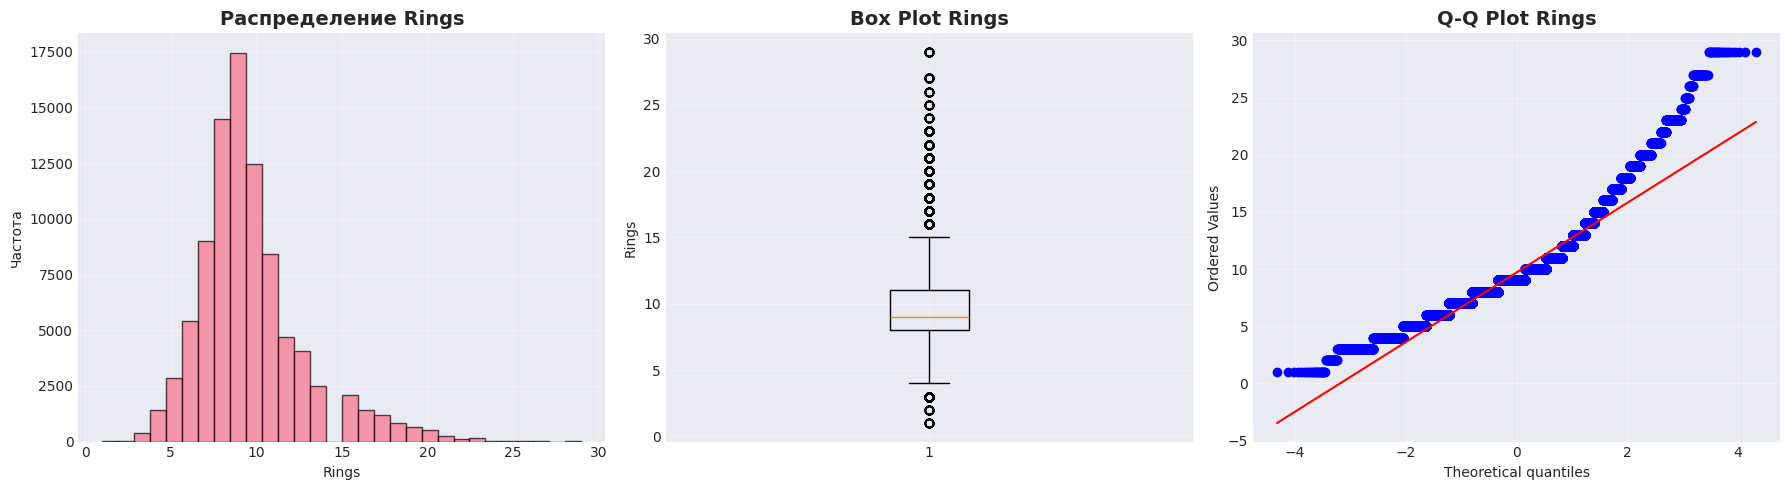

Статистика Rings:
Среднее: 9.70
Медиана: 9.00
Стандартное отклонение: 3.18
Асимметрия (Skewness): 1.20
Эксцесс (Kurtosis): 2.61
Минимум: 1
Максимум: 29


In [90]:
# Анализ целевой переменной (Rings)
target = 'Rings'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма
axes[0].hist(df[target], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Распределение {target}', fontsize=14, fontweight='bold')
axes[0].set_xlabel(target)
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df[target], vert=True)
axes[1].set_title(f'Box Plot {target}', fontsize=14, fontweight='bold')
axes[1].set_ylabel(target)
axes[1].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(df[target], dist="norm", plot=axes[2])
axes[2].set_title(f'Q-Q Plot {target}', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Статистика {target}:")
print(f"Среднее: {df[target].mean():.2f}")
print(f"Медиана: {df[target].median():.2f}")
print(f"Стандартное отклонение: {df[target].std():.2f}")
print(f"Асимметрия (Skewness): {df[target].skew():.2f}")
print(f"Эксцесс (Kurtosis): {df[target].kurtosis():.2f}")
print(f"Минимум: {df[target].min()}")
print(f"Максимум: {df[target].max()}")

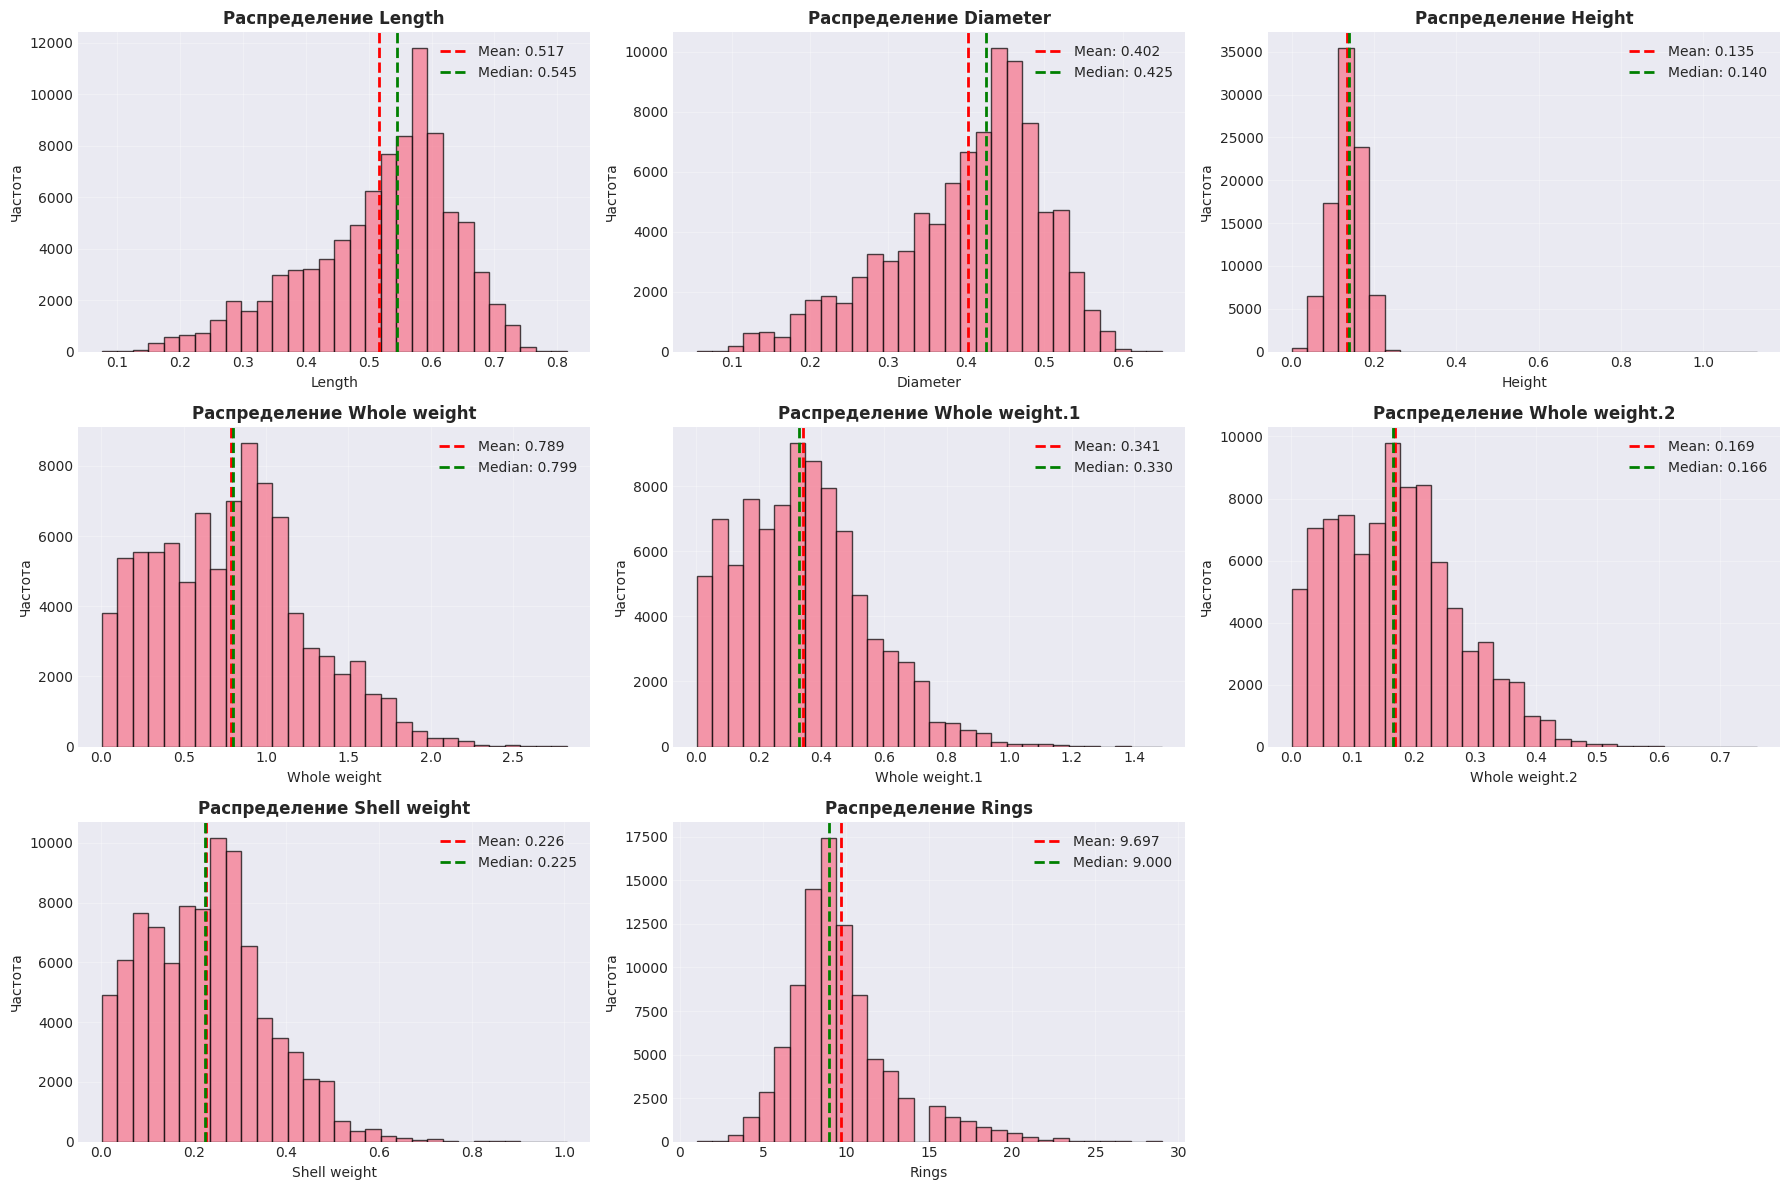

In [91]:
# Распределения числовых признаков
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'id']

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Распределение {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(True, alpha=0.3)
    
    # Добавляем статистику
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.3f}')
    axes[idx].legend()

# Скрываем лишние подграфики
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Поиск выбросов

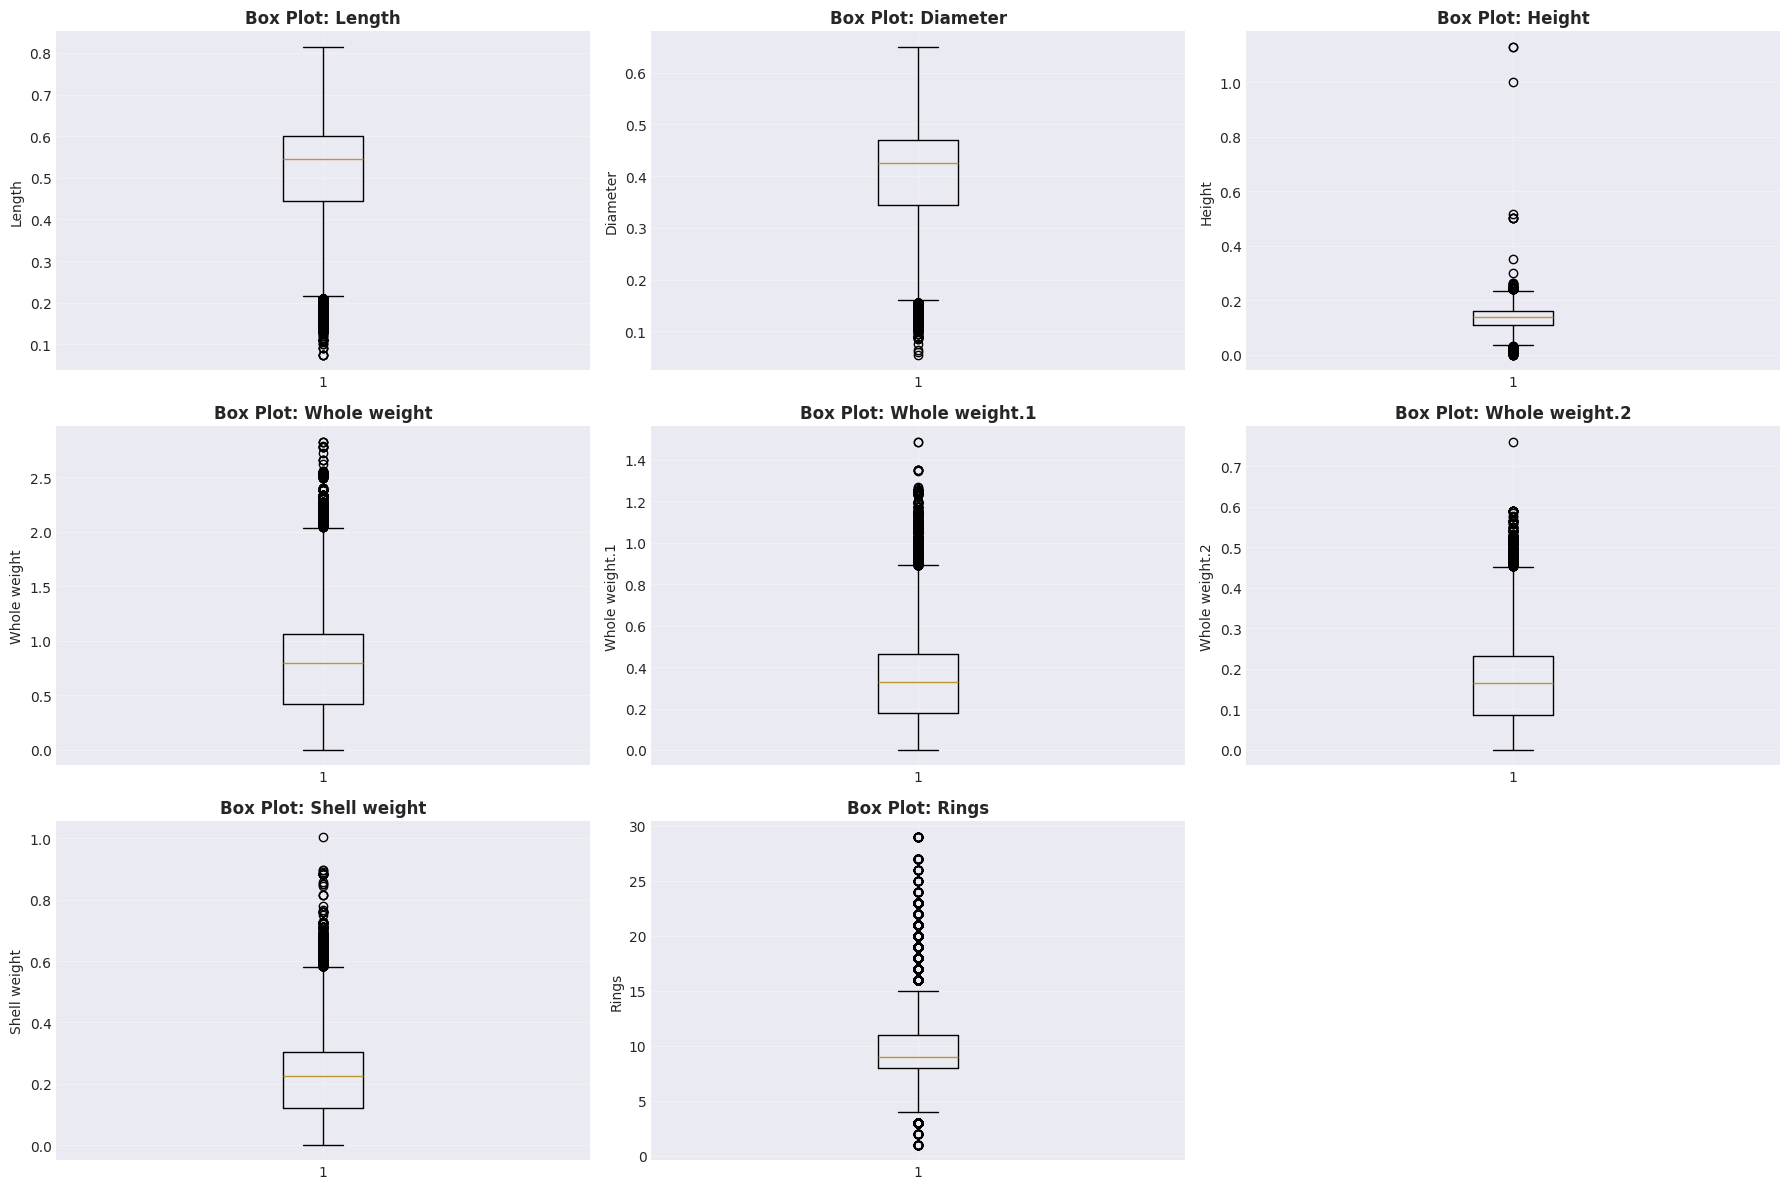

In [92]:
# Box plots для всех числовых признаков
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_title(f'Box Plot: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [93]:
# Количественная оценка выбросов (метод IQR)
outliers_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(outliers)
    outliers_percent = 100 * outliers_count / len(df)
    
    outliers_summary.append({
        'Признак': col,
        'Количество выбросов': outliers_count,
        'Процент': f'{outliers_percent:.2f}%',
        'Нижняя граница': f'{lower_bound:.4f}',
        'Верхняя граница': f'{upper_bound:.4f}'
    })

outliers_df = pd.DataFrame(outliers_summary)
print("Анализ выбросов (метод IQR):")
print(outliers_df.to_string(index=False))

Анализ выбросов (метод IQR):
       Признак  Количество выбросов Процент Нижняя граница Верхняя граница
        Length                 1460   1.61%         0.2125          0.8325
      Diameter                 1580   1.74%         0.1575          0.6575
        Height                  348   0.38%         0.0350          0.2350
  Whole weight                  574   0.63%        -0.5537          2.0402
Whole weight.1                  967   1.07%        -0.2508          0.8913
Whole weight.2                  440   0.49%        -0.1325          0.4515
  Shell weight                  671   0.74%        -0.1575          0.5825
         Rings                 5725   6.32%         3.5000         15.5000


## Анализ категориальных признаков


Анализ признака 'Sex':
     Количество    Процент
Sex                       
I         33093  36.520444
M         31027  34.240468
F         26495  29.239088


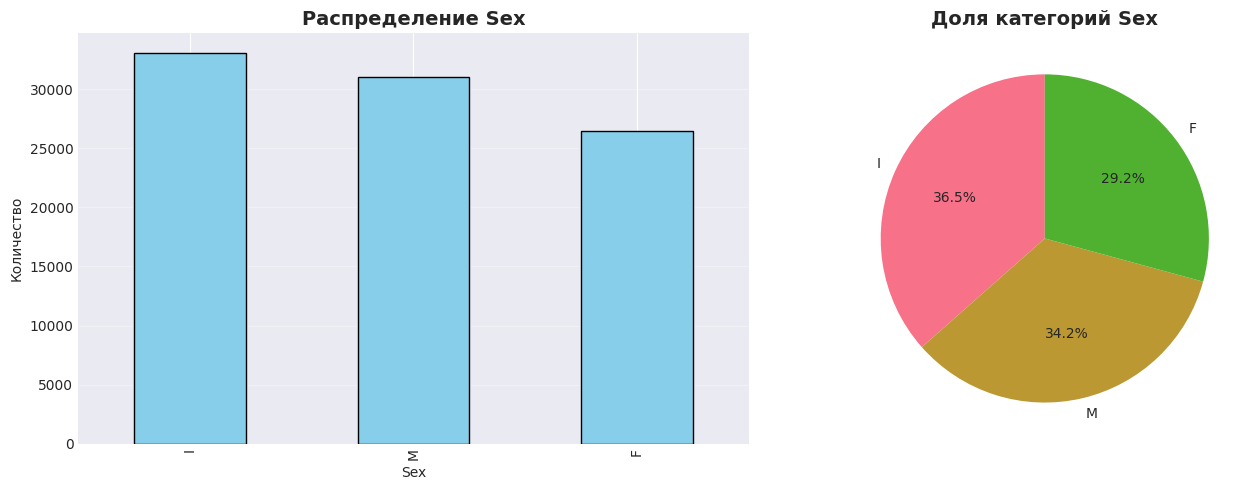

In [94]:
# Анализ признака Sex
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    print(f"\nАнализ признака '{col}':")
    print("="*50)
    value_counts = df[col].value_counts()
    value_percent = 100 * df[col].value_counts(normalize=True)
    
    summary = pd.DataFrame({
        'Количество': value_counts,
        'Процент': value_percent
    })
    print(summary)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    value_counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Распределение {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Количество')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    axes[1].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Доля категорий {col}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

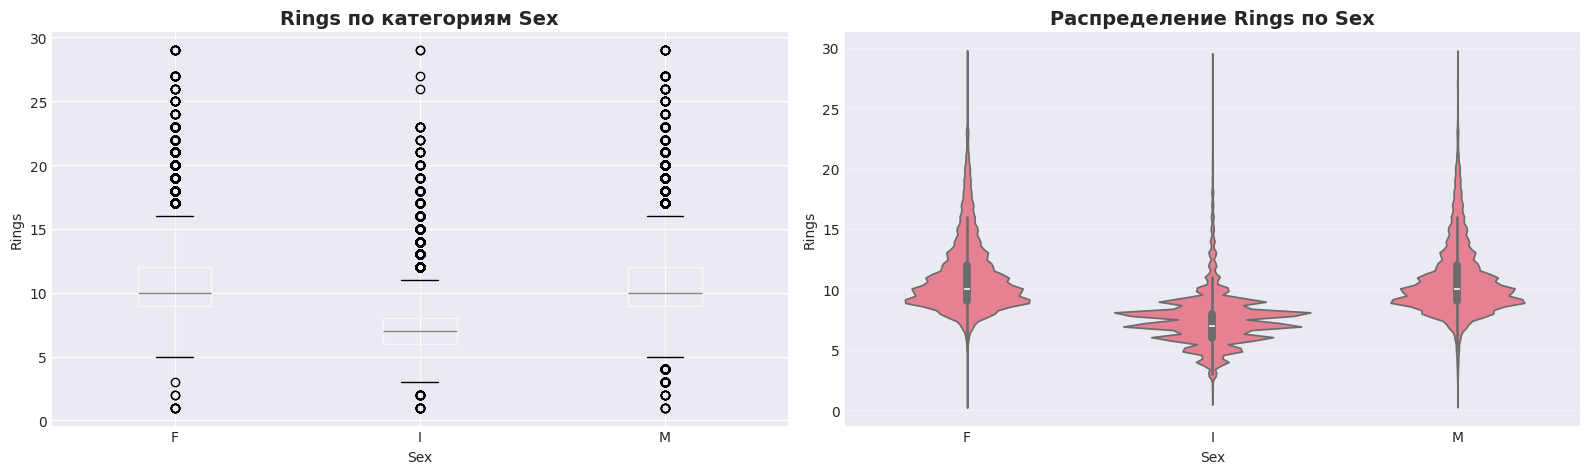


Статистика Rings по категориям Sex:
       count       mean       std  min  25%   50%   75%   max
Sex                                                          
F    26495.0  11.161389  3.021624  1.0  9.0  10.0  12.0  29.0
I    33093.0   7.533557  2.131495  1.0  6.0   7.0   8.0  29.0
M    31027.0  10.753408  2.980265  1.0  9.0  10.0  12.0  29.0


In [95]:
# Связь категориальных признаков с целевой переменной
if len(categorical_cols) > 0:
    for col in categorical_cols:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # Box plot
        df.boxplot(column=target, by=col, ax=axes[0])
        axes[0].set_title(f'{target} по категориям {col}', fontsize=14, fontweight='bold')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel(target)
        plt.suptitle('')
        
        # Violin plot
        sns.violinplot(data=df, x=col, y=target, ax=axes[1])
        axes[1].set_title(f'Распределение {target} по {col}', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        # Статистика по группам
        print(f"\nСтатистика {target} по категориям {col}:")
        print(df.groupby(col)[target].describe())
        print("="*70)

## Вычисление корреляций

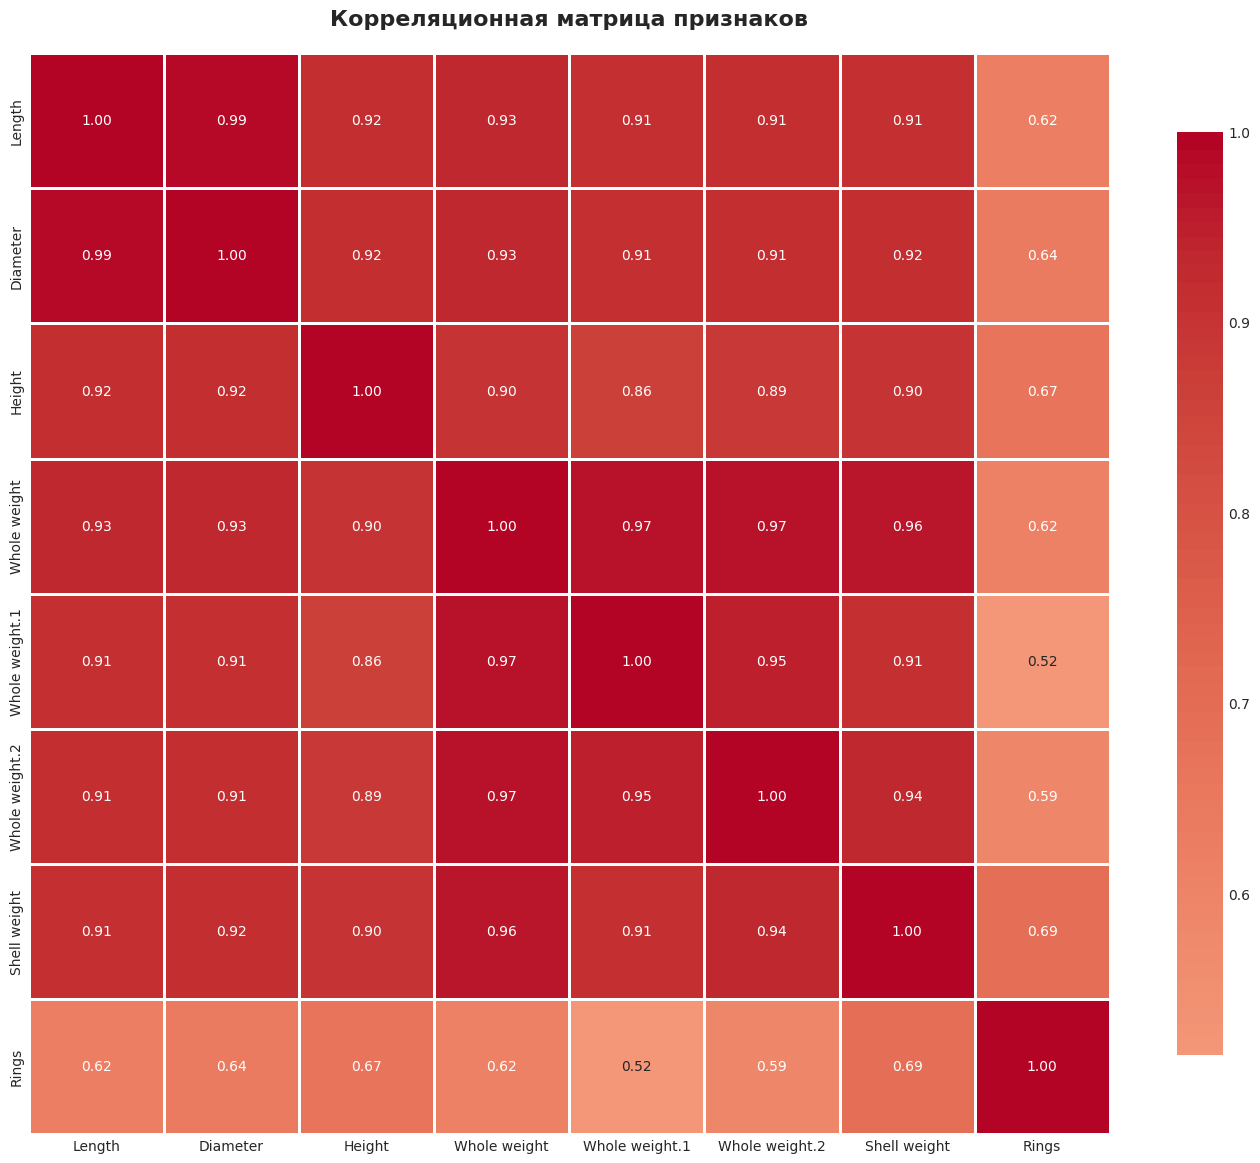


Корреляция признаков с целевой переменной (Rings):
Rings             1.000000
Shell weight      0.694766
Height            0.665772
Diameter          0.636832
Length            0.623786
Whole weight      0.617274
Whole weight.2    0.588954
Whole weight.1    0.515067
Name: Rings, dtype: float64


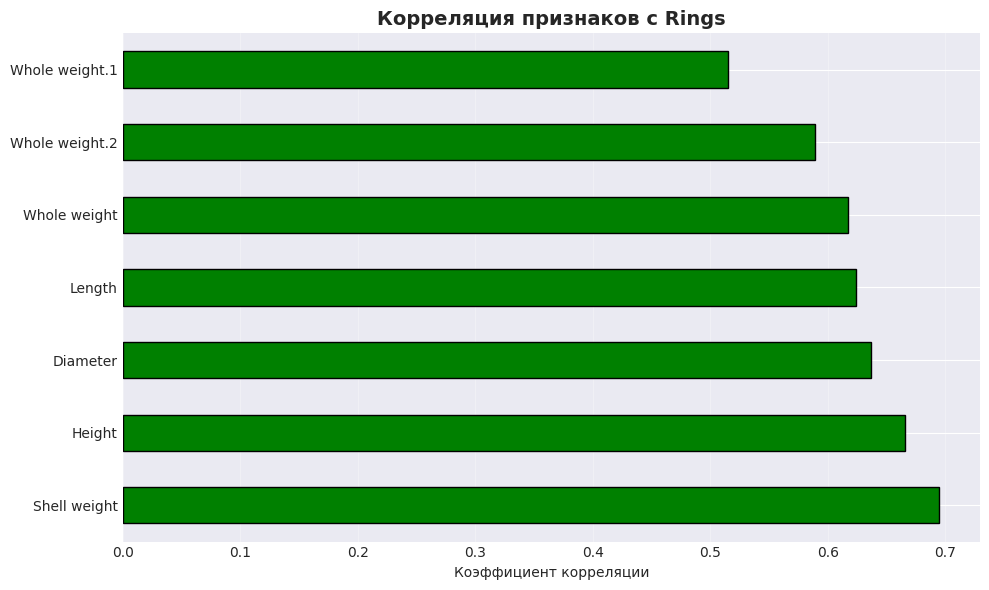

In [96]:
# Корреляционная матрица
numeric_df = df[numeric_cols]
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Корреляция с целевой переменной
target_corr = correlation_matrix[target].sort_values(ascending=False)
print("\nКорреляция признаков с целевой переменной (Rings):")
print("="*50)
print(target_corr)

# Визуализация корреляции с целевой переменной
plt.figure(figsize=(10, 6))
target_corr_filtered = target_corr[target_corr.index != target]
colors = ['green' if x > 0 else 'red' for x in target_corr_filtered.values]
target_corr_filtered.plot(kind='barh', color=colors, edgecolor='black')
plt.title(f'Корреляция признаков с {target}', fontsize=14, fontweight='bold')
plt.xlabel('Коэффициент корреляции')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [97]:
# Поиск сильно коррелирующих признаков (мультиколлинеарность)
high_corr_pairs = []
threshold = 0.8

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            high_corr_pairs.append({
                'Признак 1': correlation_matrix.columns[i],
                'Признак 2': correlation_matrix.columns[j],
                'Корреляция': f'{correlation_matrix.iloc[i, j]:.4f}'
            })

if len(high_corr_pairs) > 0:
    print(f"\nСильно коррелирующие пары признаков (|r| >= {threshold}):")
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print(f"\nСильно коррелирующих пар признаков не обнаружено (|r| >= {threshold})")


Сильно коррелирующие пары признаков (|r| >= 0.8):
     Признак 1      Признак 2 Корреляция
        Length       Diameter     0.9897
        Length         Height     0.9161
        Length   Whole weight     0.9314
        Length Whole weight.1     0.9096
        Length Whole weight.2     0.9131
        Length   Shell weight     0.9111
      Diameter         Height     0.9196
      Diameter   Whole weight     0.9338
      Diameter Whole weight.1     0.9085
      Diameter Whole weight.2     0.9147
      Diameter   Shell weight     0.9179
        Height   Whole weight     0.9023
        Height Whole weight.1     0.8618
        Height Whole weight.2     0.8861
        Height   Shell weight     0.9040
  Whole weight Whole weight.1     0.9712
  Whole weight Whole weight.2     0.9743
  Whole weight   Shell weight     0.9642
Whole weight.1 Whole weight.2     0.9492
Whole weight.1   Shell weight     0.9118
Whole weight.2   Shell weight     0.9371


## Визуализация взаимосвязей

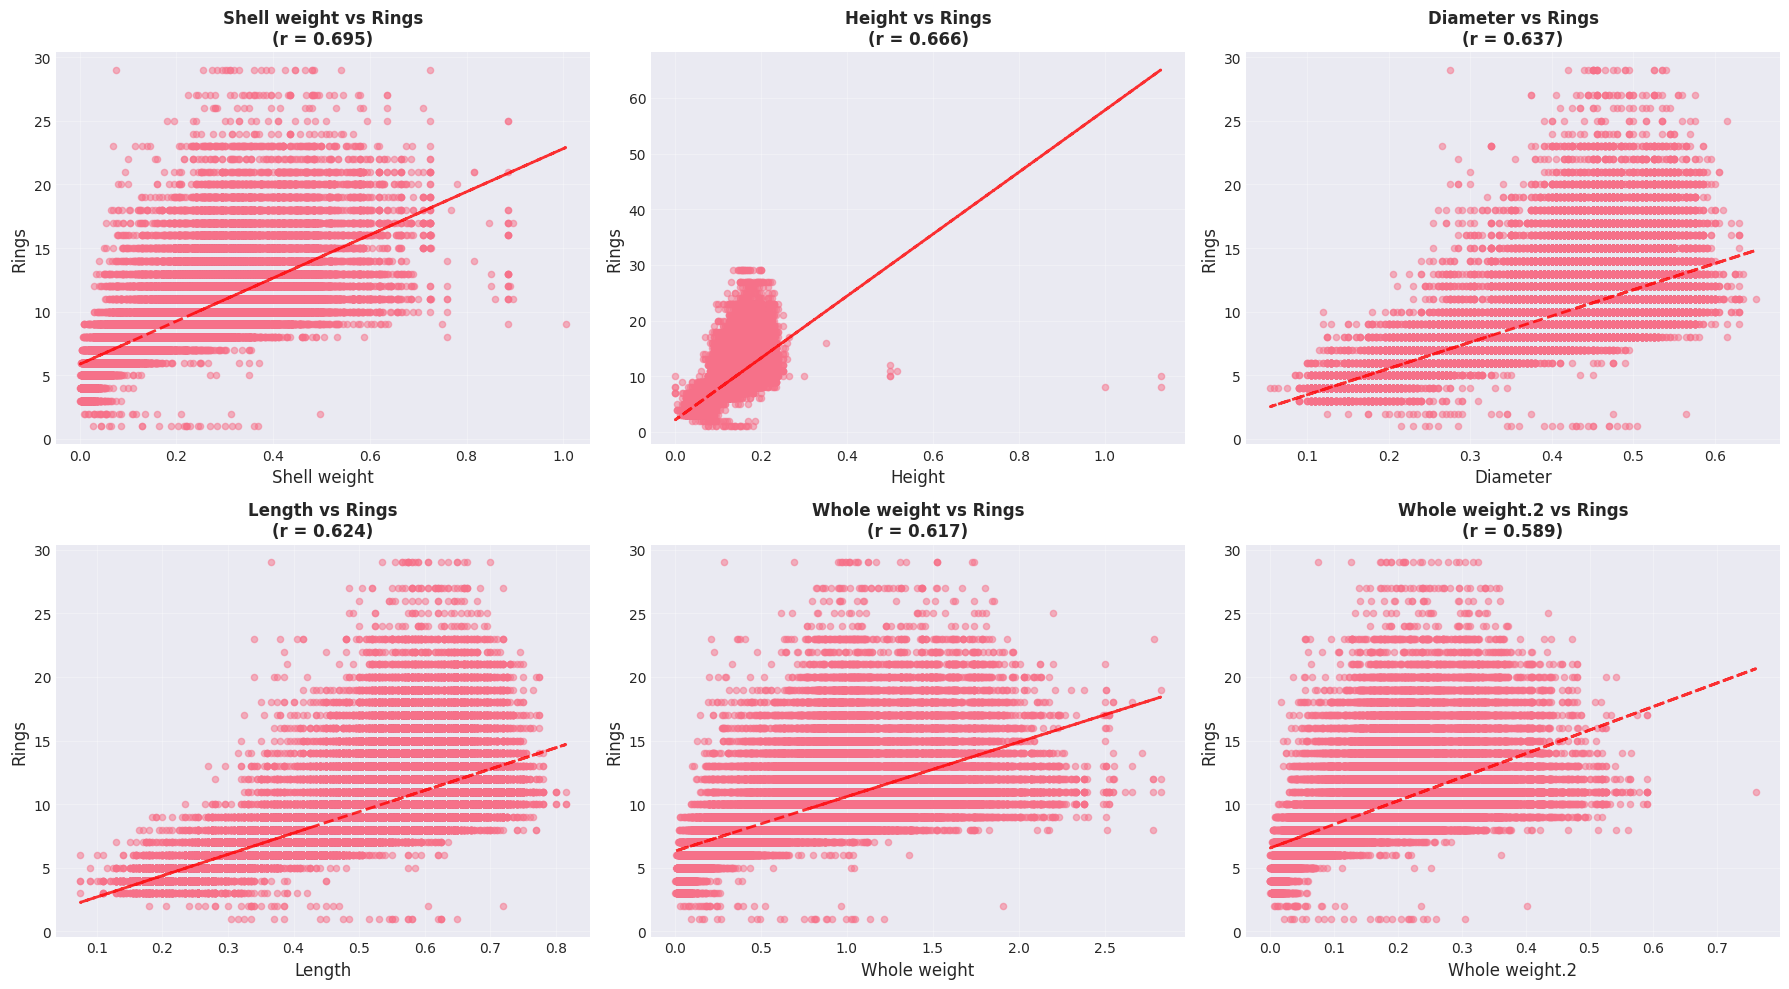

In [98]:
# Scatter plots для наиболее коррелирующих признаков с целевой переменной
top_features = target_corr_filtered.abs().sort_values(ascending=False).head(6).index.tolist()

n_features = len(top_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df[target], alpha=0.5, s=20)
    axes[idx].set_xlabel(feature, fontsize=12)
    axes[idx].set_ylabel(target, fontsize=12)
    axes[idx].set_title(f'{feature} vs {target}\n(r = {correlation_matrix.loc[feature, target]:.3f})', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Добавляем линию тренда
    z = np.polyfit(df[feature], df[target], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2)

for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

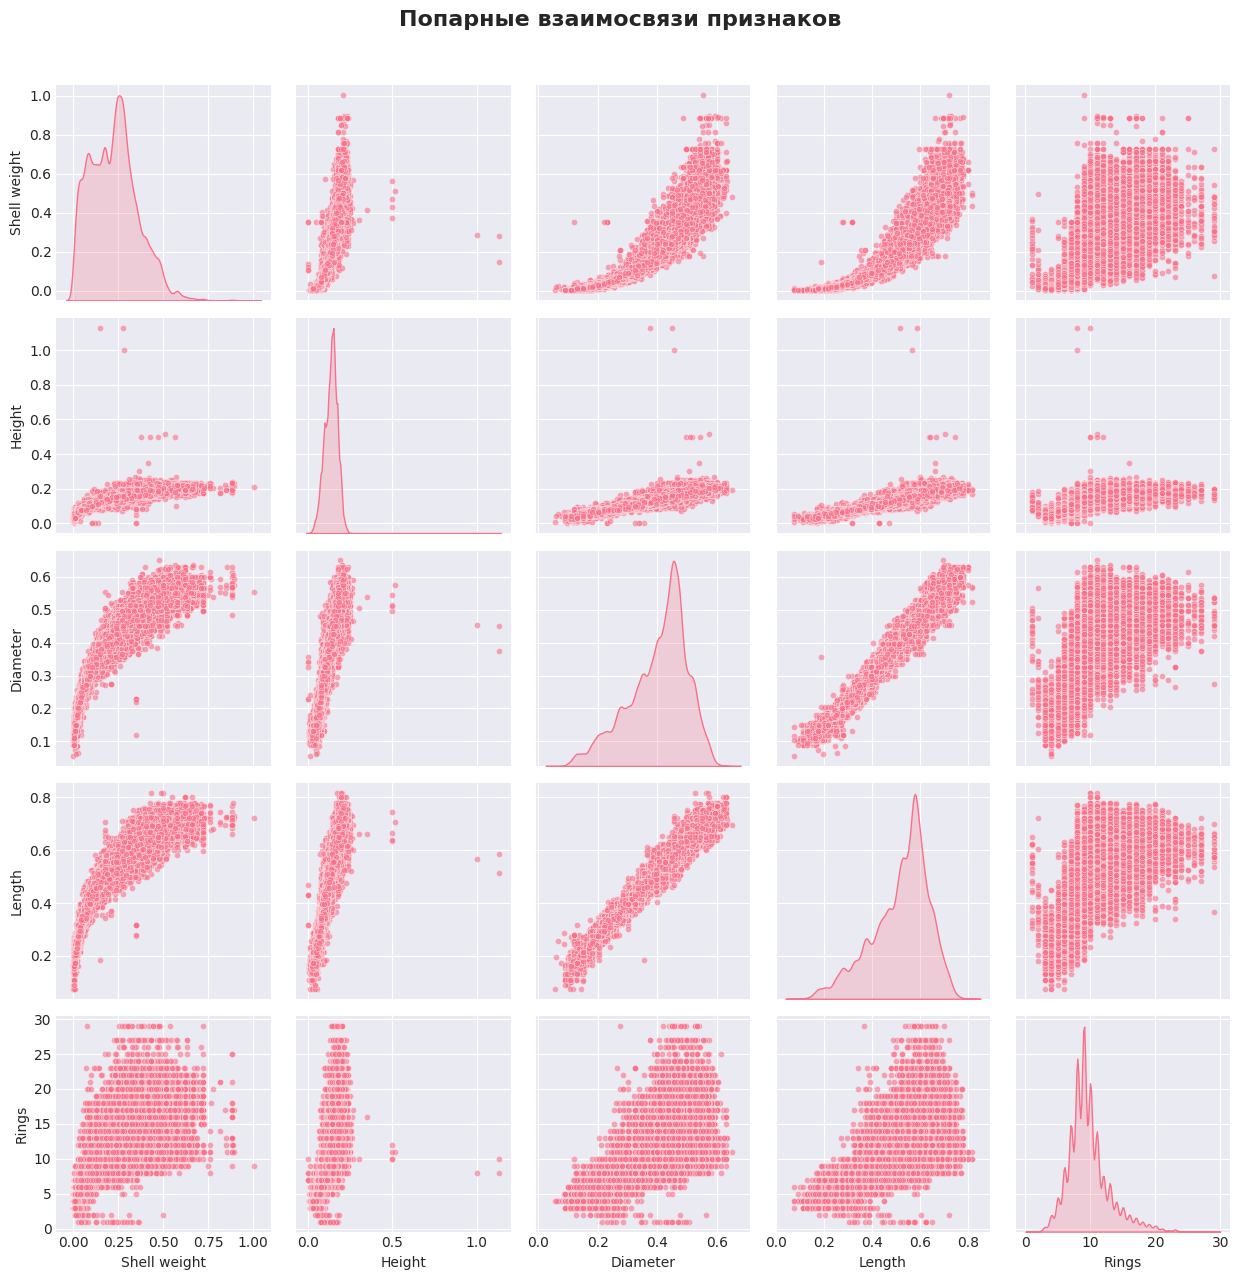

In [99]:
# Pair plot для топ признаков
selected_features = top_features[:4] + [target]
sns.pairplot(df[selected_features], diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
plt.suptitle('Попарные взаимосвязи признаков', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Анализ баланса классов / распределения целевой переменной

Уникальные значения Rings: 28
Диапазон: 1 - 29

Распределение по количеству колец:
Rings
1        25
2        29
3       386
4      1402
5      2862
6      5411
7      9008
8     14499
9     17465
10    12464
11     8407
12     4719
13     4074
14     2507
15     2072
16     1439
17     1175
18      848
19      639
20      507
21      255
22      108
23      180
24       29
25       22
26       18
27       41
29       24
Name: count, dtype: int64


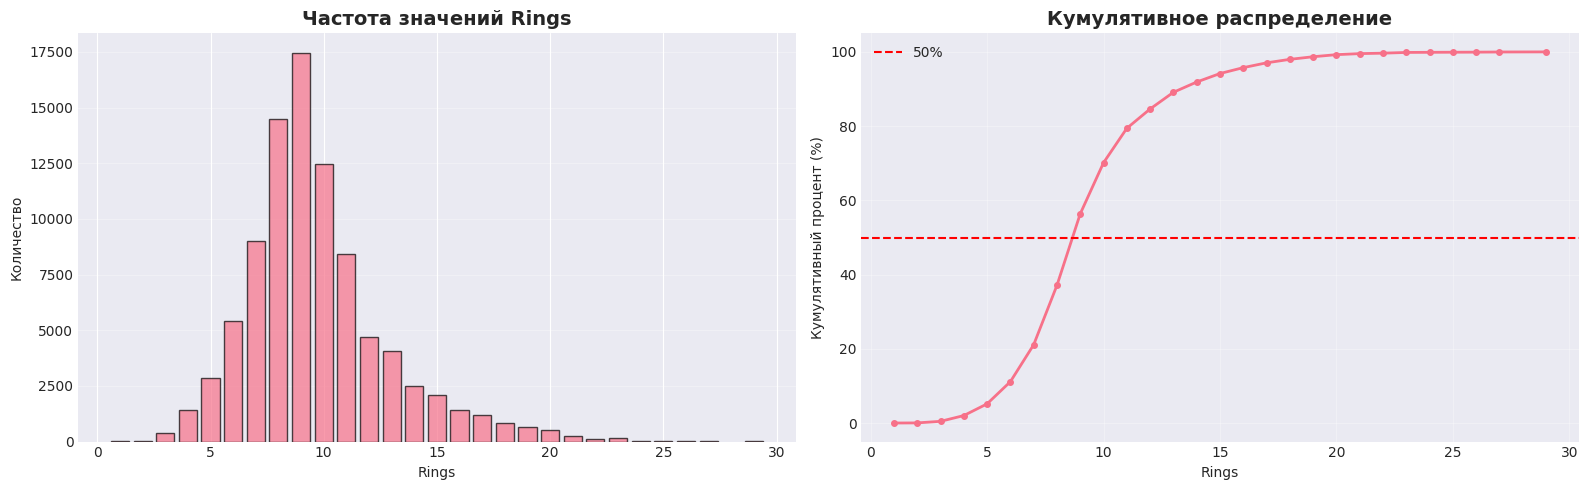


Соотношение дисбаланса (макс/мин): 970.28


In [100]:
# Детальный анализ распределения целевой переменной
rings_distribution = df[target].value_counts().sort_index()

print(f"Уникальные значения {target}: {df[target].nunique()}")
print(f"Диапазон: {df[target].min()} - {df[target].max()}")
print("\nРаспределение по количеству колец:")
print(rings_distribution)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Распределение
axes[0].bar(rings_distribution.index, rings_distribution.values, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Частота значений {target}', fontsize=14, fontweight='bold')
axes[0].set_xlabel(target)
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3, axis='y')

# Кумулятивное распределение
cumulative = rings_distribution.sort_index().cumsum() / len(df) * 100
axes[1].plot(cumulative.index, cumulative.values, marker='o', linewidth=2, markersize=4)
axes[1].set_title('Кумулятивное распределение', fontsize=14, fontweight='bold')
axes[1].set_xlabel(target)
axes[1].set_ylabel('Кумулятивный процент (%)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=50, color='r', linestyle='--', label='50%')
axes[1].legend()

plt.tight_layout()
plt.show()

# Проверка на балансировку 
most_common = rings_distribution.max()
least_common = rings_distribution.min()
imbalance_ratio = most_common / least_common
print(f"\nСоотношение дисбаланса (макс/мин): {imbalance_ratio:.2f}")

## Поиск дубликатов

In [101]:
# Полные дубликаты
duplicates_full = df.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates_full}")

if duplicates_full > 0:
    print("\nПримеры дубликатов:")
    print(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))

# Дубликаты по признакам (без id)
features_for_duplicates = [col for col in df.columns if col != 'id']
duplicates_features = df.duplicated(subset=features_for_duplicates).sum()
print(f"\nКоличество дубликатов по признакам (без id): {duplicates_features}")

if duplicates_features > 0:
    print("\nПримеры дубликатов по признакам:")
    print(df[df.duplicated(subset=features_for_duplicates, keep=False)].sort_values(by=features_for_duplicates).head(10))

Количество полных дубликатов: 0

Количество дубликатов по признакам (без id): 0


## Проверка логической согласованности данных

In [102]:
# Проверка логических связей между признаками
print("Проверка логической согласованности данных:\n")

# 1. Проверка: Height должна быть меньше Length и Diameter
inconsistent_height = df[(df['Height'] > df['Length']) | (df['Height'] > df['Diameter'])]
print(f"1. Записей где Height > Length или Height > Diameter: {len(inconsistent_height)}")
if len(inconsistent_height) > 0:
    print("   Примеры:")
    print(inconsistent_height[['Length', 'Diameter', 'Height']].head())

# 2. Проверка: Whole weight должен быть больше или равен сумме остальных весов
weight_cols = [col for col in df.columns if 'weight' in col.lower()]
if len(weight_cols) >= 4:
    df_temp = df.copy()
    # Предполагаем, что Whole weight - это первый столбец с weight
    # и остальные Whole weight.1, Whole weight.2, Shell weight - это компоненты
    sum_components = df_temp['Whole weight.1'] + df_temp['Whole weight.2'] + df_temp['Shell weight']
    inconsistent_weight = df_temp[df_temp['Whole weight'] < (sum_components - 0.001)]  # небольшая погрешность
    print(f"\n2. Записей где Whole weight < сумма компонентов: {len(inconsistent_weight)}")
    if len(inconsistent_weight) > 0:
        print("   Примеры:")
        print(inconsistent_weight[weight_cols].head())

# 3. Проверка отрицательных значений
negative_values = {}
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        negative_values[col] = neg_count

if len(negative_values) > 0:
    print("\n3. Признаки с отрицательными значениями:")
    for col, count in negative_values.items():
        print(f"   {col}: {count} записей")
else:
    print("\n3. Отрицательных значений не обнаружено")

# 4. Проверка нулевых значений в физических измерениях
physical_features = ['Length', 'Diameter', 'Height']
zero_physical = {}
for col in physical_features:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        if zero_count > 0:
            zero_physical[col] = zero_count

if len(zero_physical) > 0:
    print("\n4. Нулевые значения в физических измерениях:")
    for col, count in zero_physical.items():
        print(f"   {col}: {count} записей")
else:
    print("\n4. Нулевых значений в физических измерениях не обнаружено")

# 5. Проверка соотношения Length и Diameter
unusual_ratio = df[df['Diameter'] > df['Length']]
print(f"\n5. Записей где Diameter > Length: {len(unusual_ratio)}")
if len(unusual_ratio) > 0:
    print("   Примеры:")
    print(unusual_ratio[['Length', 'Diameter']].head())

Проверка логической согласованности данных:

1. Записей где Height > Length или Height > Diameter: 4
   Примеры:
       Length  Diameter  Height
16384   0.515     0.375    1.13
58048   0.635     0.495    0.50
65464   0.585     0.450    1.13
77326   0.565     0.455    1.00

2. Записей где Whole weight < сумма компонентов: 10439
   Примеры:
    Whole weight  Whole weight.1  Whole weight.2  Shell weight
6         0.3315          0.1655          0.0715         0.130
9         0.6510          0.3795          0.1420         0.180
10        0.6335          0.3035          0.1650         0.200
16        0.1965          0.0960          0.0540         0.055
24        0.7955          0.3885          0.1925         0.220

3. Отрицательных значений не обнаружено

4. Нулевые значения в физических измерениях:
   Height: 6 записей

5. Записей где Diameter > Length: 20
   Примеры:
       Length  Diameter
2539    0.130     0.150
6700    0.145     0.155
11031   0.090     0.100
18320   0.140     0.145
253

## Выявление потенциально важных признаков

Потенциально важные признаки (по корреляции):
1. Shell weight: 0.6948
2. Height: 0.6658
3. Diameter: 0.6368
4. Length: 0.6238
5. Whole weight: 0.6173
6. Whole weight.2: 0.5890
7. Whole weight.1: 0.5151


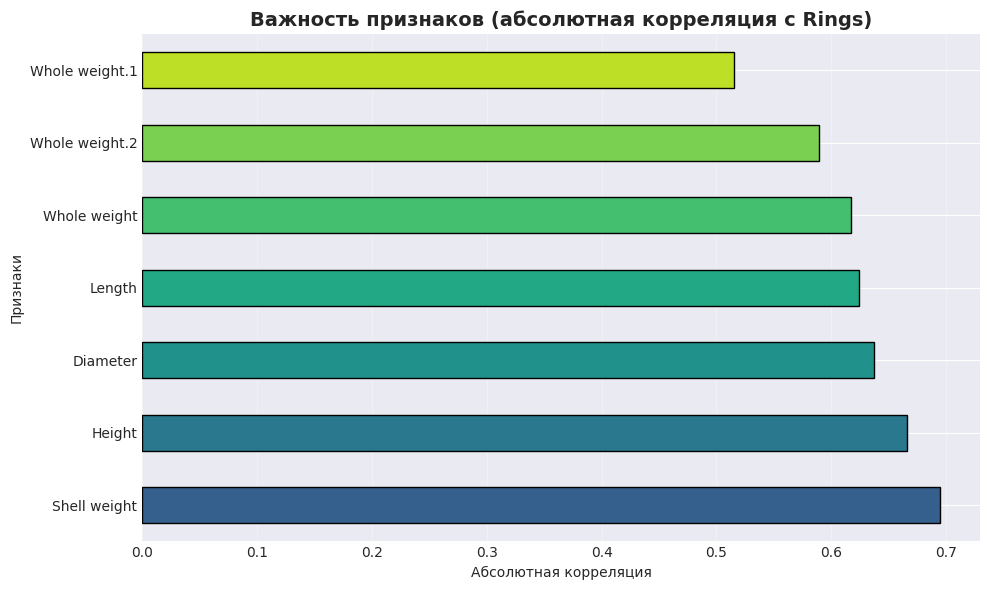

In [103]:
# Важность признаков на основе корреляции
feature_importance_corr = target_corr_filtered.abs().sort_values(ascending=False)

print("Потенциально важные признаки (по корреляции):")
print("="*50)
for idx, (feature, corr) in enumerate(feature_importance_corr.items(), 1):
    print(f"{idx}. {feature}: {corr:.4f}")

# Визуализация важности
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance_corr)))
feature_importance_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Важность признаков (абсолютная корреляция с Rings)', fontsize=14, fontweight='bold')
plt.xlabel('Абсолютная корреляция')
plt.ylabel('Признаки')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


Корреляция созданных признаков с целевой переменной:
Surface_Area: 0.6383
Volume: 0.6240
Height_to_Length: 0.3986
Shell_ratio: 0.1407
Density: -0.0047
Meat_ratio: -0.1926
Length_to_Diameter: -0.3649


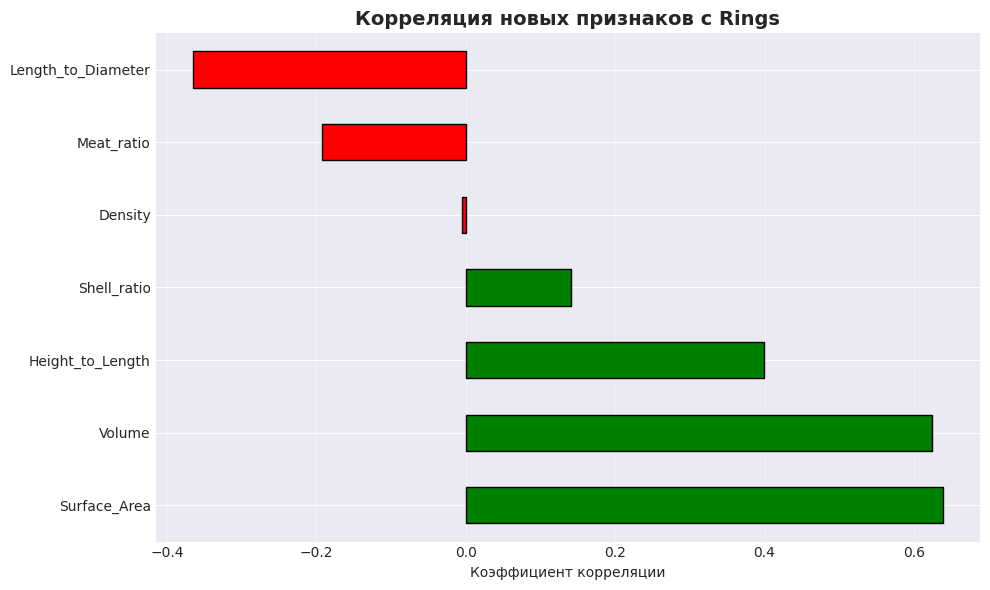

In [104]:
# Создание дополнительных признаков для анализа
df_features = df.copy()

# Объемные метрики
df_features['Volume'] = df_features['Length'] * df_features['Diameter'] * df_features['Height']
df_features['Surface_Area'] = 2 * (df_features['Length'] * df_features['Diameter'] + 
                                     df_features['Length'] * df_features['Height'] + 
                                     df_features['Diameter'] * df_features['Height'])

# Соотношения
df_features['Length_to_Diameter'] = df_features['Length'] / (df_features['Diameter'] + 1e-6)
df_features['Height_to_Length'] = df_features['Height'] / (df_features['Length'] + 1e-6)

# Доли весов
df_features['Meat_ratio'] = df_features['Whole weight.1'] / (df_features['Whole weight'] + 1e-6)
df_features['Shell_ratio'] = df_features['Shell weight'] / (df_features['Whole weight'] + 1e-6)

# Плотность
df_features['Density'] = df_features['Whole weight'] / (df_features['Volume'] + 1e-6)

# Корреляция новых признаков с целевой переменной
new_features = ['Volume', 'Surface_Area', 'Length_to_Diameter', 'Height_to_Length', 
                'Meat_ratio', 'Shell_ratio', 'Density']

new_features_corr = df_features[new_features + [target]].corr()[target].drop(target).sort_values(ascending=False)

print("\nКорреляция созданных признаков с целевой переменной:")
print("="*50)
for feature, corr in new_features_corr.items():
    print(f"{feature}: {corr:.4f}")

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in new_features_corr.values]
new_features_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Корреляция новых признаков с Rings', fontsize=14, fontweight='bold')
plt.xlabel('Коэффициент корреляции')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Итоговое резюме анализа

In [105]:
print("="*70)
print("ИТОГОВОЕ РЕЗЮМЕ ПЕРВИЧНОГО АНАЛИЗА ДАННЫХ")
print("="*70)

print(f"\n1. ОБЩАЯ ИНФОРМАЦИЯ:")
print(f"   - Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"   - Числовых признаков: {len(numeric_cols)}")
print(f"   - Категориальных признаков: {len(categorical_cols)}")
print(f"   - Целевая переменная: {target} (диапазон: {df[target].min()}-{df[target].max()})")

print(f"\n2. КАЧЕСТВО ДАННЫХ:")
print(f"   - Пропущенные значения: {'Отсутствуют' if missing_table.empty else f'{missing_table.shape[0]} признаков'}")
print(f"   - Полные дубликаты: {duplicates_full}")
print(f"   - Дубликаты по признакам: {duplicates_features}")

print(f"\n3. РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
print(f"   - Среднее: {df[target].mean():.2f}")
print(f"   - Медиана: {df[target].median():.2f}")
print(f"   - Стандартное отклонение: {df[target].std():.2f}")
print(f"   - Асимметрия: {df[target].skew():.2f}")
print(f"   - Уникальных значений: {df[target].nunique()}")

print(f"\n4. ТОП-5 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ:")
for idx, (feature, corr) in enumerate(feature_importance_corr.head(5).items(), 1):
    print(f"   {idx}. {feature}: r = {corr:.4f}")

print(f"\n5. МУЛЬТИКОЛЛИНЕАРНОСТЬ:")
if len(high_corr_pairs) > 0:
    print(f"   - Обнаружено {len(high_corr_pairs)} сильно коррелирующих пар")
    for pair in high_corr_pairs[:3]:
        print(f"     • {pair['Признак 1']} ↔ {pair['Признак 2']}: {pair['Корреляция']}")
else:
    print(f"   - Сильной мультиколлинеарности не обнаружено")

print(f"\n6. ВЫБРОСЫ (топ-3 признака):")
outliers_sorted = sorted(outliers_summary, key=lambda x: x['Количество выбросов'], reverse=True)[:3]
for item in outliers_sorted:
    print(f"   - {item['Признак']}: {item['Количество выбросов']} ({item['Процент']})")

print("\n" + "="*70)

ИТОГОВОЕ РЕЗЮМЕ ПЕРВИЧНОГО АНАЛИЗА ДАННЫХ

1. ОБЩАЯ ИНФОРМАЦИЯ:
   - Размер датасета: 90615 строк, 10 столбцов
   - Числовых признаков: 8
   - Категориальных признаков: 1
   - Целевая переменная: Rings (диапазон: 1-29)

2. КАЧЕСТВО ДАННЫХ:
   - Пропущенные значения: Отсутствуют
   - Полные дубликаты: 0
   - Дубликаты по признакам: 0

3. РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
   - Среднее: 9.70
   - Медиана: 9.00
   - Стандартное отклонение: 3.18
   - Асимметрия: 1.20
   - Уникальных значений: 28

4. ТОП-5 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКОВ:
   1. Shell weight: r = 0.6948
   2. Height: r = 0.6658
   3. Diameter: r = 0.6368
   4. Length: r = 0.6238
   5. Whole weight: r = 0.6173

5. МУЛЬТИКОЛЛИНЕАРНОСТЬ:
   - Обнаружено 21 сильно коррелирующих пар
     • Length ↔ Diameter: 0.9897
     • Length ↔ Height: 0.9161
     • Length ↔ Whole weight: 0.9314

6. ВЫБРОСЫ (топ-3 признака):
   - Rings: 5725 (6.32%)
   - Diameter: 1580 (1.74%)
   - Length: 1460 (1.61%)

